<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS06/JS06_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS06 - Klasifikasi 2: Lab 3 (SVM Data Overlapping)

Pada dua praktikum sebelumnya, decision boundaries dapat memisahkan data secara jelas karena tidak terdapat data yang tumpang tindih (*overlapping*). Pada praktikum ini kita mempelajari *hyperparameter tuning* - menyesuaikan parameter model (khususnya $C$) agar dapat mengatasi data yang tumpang tindih.


## Langkah 1 - Import Library dan Buat Fungsi Plotting

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## Langkah 2 - Buat Data Dummy

Data dibuat dengan `cluster_std=1.2` sehingga sebaran kedua kelas saling tumpang tindih.

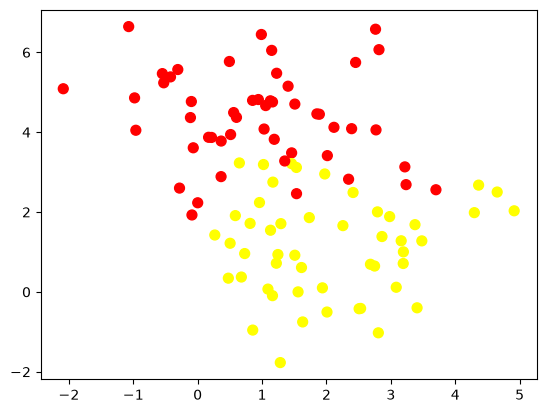

In [3]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

## Langkah 3 - Analisis Dampak Tuning

Untuk mengatasi data tumpang tindih, teknik **penghalusan margin** dapat diterapkan: beberapa titik data diizinkan masuk ke dalam margin supaya menghasilkan fitting yang lebih baik. Penebalan margin ini dikelola oleh parameter tuning $C$. Contoh berikut menunjukkan perubahan $C$ dan dampaknya pada hasil fitting final.

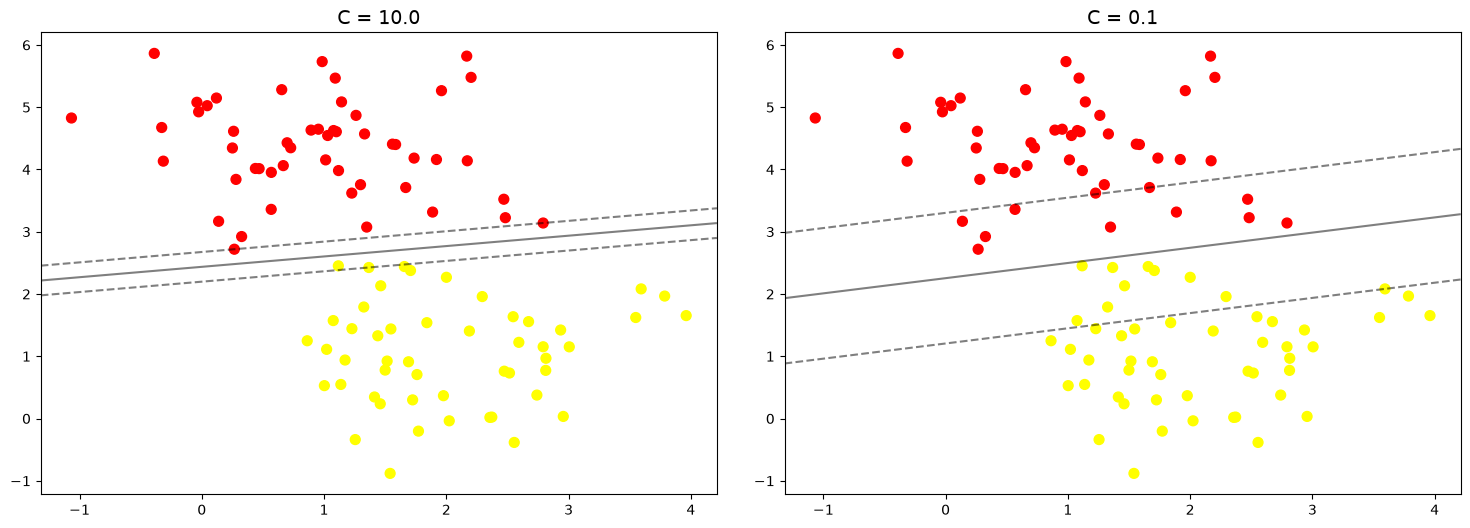

In [4]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

**Analisis:**

* $C = 10.0$ (nilai besar): margin lebih **keras/rapat** - model berusaha keras memisahkan semua titik training sehingga sensitif terhadap noise (*overfitting*).
* $C = 0.1$ (nilai kecil): margin lebih **tebal/lembut** - beberapa titik training diizinkan salah masuk margin sehingga generalisasi lebih baik pada data yang tumpang tindih.

Perlu diperhatikan bahwa **nilai optimal $C$ bergantung pada setiap dataset** dan sebaiknya ditentukan melalui *cross-validation* atau prosedur serupa (contoh penerapannya pada Lab 4 dengan `GridSearchCV`).